Notebook to check if there are negative parameters in the demirtas paper data

In [1]:
import numpy as np
import os
from hbnm.io import Data
from hbnm.bnm import Bnm
from hbnm.model.utils import subdiag, fisher_z
from scipy.spatial.distance import squareform


### Compare Demirtas Homogenous and Heterogenous fits vs Ours

In [2]:
"""
Set directories
"""
current_path = os.getcwd()
# parent_path = os.path.abspath(os.path.join(current_path, os.pardir))
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'

"""
Load data
"""
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 
fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
print(fin.keys())
theta_heterogeneous_dem = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous_dem = fin['apprx_posterior_homogeneous'][:]
fin.close()



<KeysViewHDF5 ['alphabeta_removed_meg_pc1', 'apprx_posterior_heterogeneous', 'apprx_posterior_homogeneous', 'fc', 'fc_heterogeneous', 'fc_homogeneous', 'heterogeneity_maps', 'raw_meg_pc1', 'sc', 't1wt2w']>


In [8]:
# Load homogenous fitted model parameters
fin_homogenous = data.load('Homogenous/iteration_20.hdf5', from_output=True)
# Extract posterior samples and weights
theta_homogeneous_fra = fin_homogenous['theta'][:]  # Shape: (n_params, n_samples)
fin_homogenous.close()

# Load heterogeneous fitted model parameters
fin_heterogeneous = data.load('Heterogeneous_Dem_Range/iteration_53.hdf5', from_output=True)
theta_heterogeneous_fra = fin_heterogeneous['theta'][:]
fin_heterogeneous.close()

In [9]:
homo_params = ['w_EI', 'w_EE', 'G']
het_params = ['w_EI', 'w_EI_scale', 'w_EE', 'w_EE_scale', 'G']



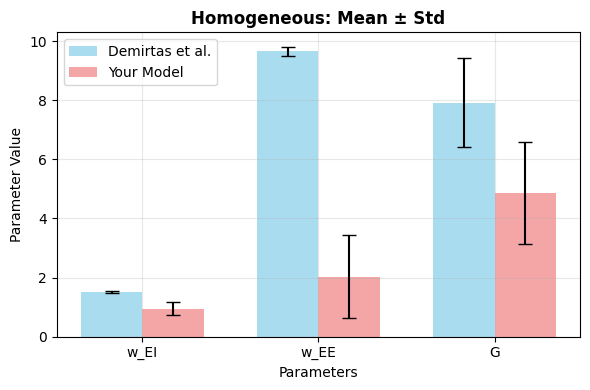

In [10]:
# Calculate means and standard errors
dem_means = [np.mean(theta_homogeneous_dem[i, :]) for i in range(len(homo_params))]
dem_stds = [np.std(theta_homogeneous_dem[i, :]) for i in range(len(homo_params))]
fra_means = [np.mean(theta_homogeneous_fra[i, :]) for i in range(len(homo_params))]
fra_stds = [np.std(theta_homogeneous_fra[i, :]) for i in range(len(homo_params))]

import matplotlib.pyplot as plt

# Set up figure and axis if not already defined
fig3, ax3 = plt.subplots(figsize=(6, 4))

x_pos = np.arange(len(homo_params))
width = 0.35

# Plot Demirtas et al. means and stds
ax3.bar(x_pos - width/2, dem_means, width, yerr=dem_stds, label='Demirtas et al.',
        color='skyblue', alpha=0.7, capsize=5)
# Plot your model means and stds
ax3.bar(x_pos + width/2, fra_means, width, yerr=fra_stds, label='Your Model',
        color='lightcoral', alpha=0.7, capsize=5)

ax3.set_title('Homogeneous: Mean ± Std', fontweight='bold')
ax3.set_ylabel('Parameter Value')
ax3.set_xlabel('Parameters')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(homo_params)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


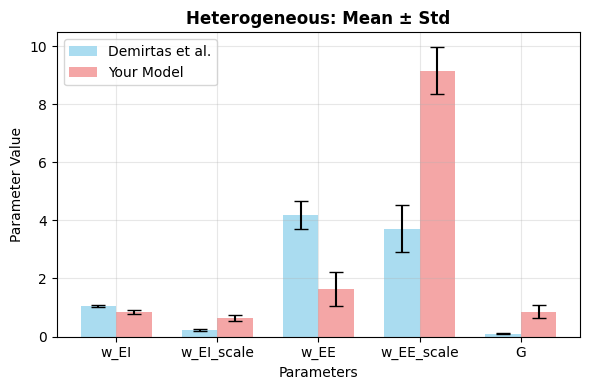

In [11]:
# Calculate means and standard errors
dem_means = [np.mean(theta_heterogeneous_dem[i, :]) for i in range(len(het_params))]
dem_stds = [np.std(theta_heterogeneous_dem[i, :]) for i in range(len(het_params))]
fra_means = [np.mean(theta_heterogeneous_fra[i, :]) for i in range(len(het_params))]
fra_stds = [np.std(theta_heterogeneous_fra[i, :]) for i in range(len(het_params))]

import matplotlib.pyplot as plt

# Fix: fra_stds was incorrectly using theta_homogeneous_fra (shape 3, not 5)
# It should use theta_heterogeneous_fra (shape 5, matches het_params)
fra_stds = [np.std(theta_heterogeneous_fra[i, :]) for i in range(len(het_params))]

# Set up figure and axis for heterogeneous parameters
fig4, ax4 = plt.subplots(figsize=(6, 4))

x_pos = np.arange(len(het_params))
width = 0.35

# Plot Demirtas et al. means and stds
ax4.bar(x_pos - width/2, dem_means, width, yerr=dem_stds, label='Demirtas et al.',
        color='skyblue', alpha=0.7, capsize=5)
# Plot your model means and stds
ax4.bar(x_pos + width/2, fra_means, width, yerr=fra_stds, label='Your Model',
        color='lightcoral', alpha=0.7, capsize=5)

ax4.set_title('Heterogeneous: Mean ± Std', fontweight='bold')
ax4.set_ylabel('Parameter Value')
ax4.set_xlabel('Parameters')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(het_params)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Load homogenous fitted model parameters
fin_homogenous = data.load('Homogenous/iteration_20.hdf5', from_output=True)

# Extract posterior samples and weights
theta_homogeneous_fra = fin_homogenous['theta'][:]  # Shape: (n_params, n_samples)
weights = fin_homogenous['weights'][:]      # Shape: (n_samples,)

print(f"Theta samples shape: {theta_samples.shape}")
print(f"Weights shape: {weights.shape}")

# Compute Bayesian Model Averaging (BMA) point estimate
# Normalize weights to ensure they sum to 1
normalized_weights = weights / np.sum(weights)

# Compute weighted average for each parameter
theta_bma = np.zeros(theta_samples.shape[0])
for i in range(theta_samples.shape[0]):
    theta_bma[i] = np.sum(normalized_weights * theta_samples[i, :])

print("\nBayesian Model Averaging Results:")
print(f"BMA Parameter Estimates: {theta_bma}")

# Compare with simple posterior mean (for reference)
theta_mean = np.mean(theta_samples, axis=1)
print(f"Simple Posterior Mean: {theta_mean}")
print(f"Difference (BMA - Mean): {theta_bma - theta_mean}")

fin_homogenous.close()

# Create homogeneous model with BMA estimate
homogenous = Bnm(sc)
homogenous.set('w_EI', theta_bma[0])
homogenous.set('w_EE', theta_bma[1]) 
homogenous.set('G', theta_bma[2])

print(f"\nModel configured with BMA estimates:")
print(f"w_EI: {theta_bma[0]:.4f}")
print(f"w_EE: {theta_bma[1]:.4f}")
print(f"G: {theta_bma[2]:.4f}")

NameError: name 'theta_samples' is not defined

In [ ]:
"""
Set model samples
"""
homogeneous = Bnm(sc)
homogeneous.set('w_EI', theta_homogeneous[0,0])
homogeneous.set('w_EE', theta_homogeneous[1,0])
homogeneous.set('G', theta_homogeneous[2,0])
homogeneous.moments_method()

heterogeneous = Bnm(sc, gradient=hmap)
heterogeneous.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
heterogeneous.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
heterogeneous.set('G', theta_heterogeneous[4,0])
heterogeneous.moments_method()